In [ ]:
# CELL 1: Environment Path & Library Synchronization
from google.colab import drive
import os
import sys
import importlib

drive.mount('/content/drive')
PROJECT_PATH = '/content/drive/MyDrive/adaptive_crypto_framework'
os.makedirs(os.path.join(PROJECT_PATH, 'tests'), exist_ok=True)
os.chdir(PROJECT_PATH)

if PROJECT_PATH not in sys.path:
    sys.path.append(PROJECT_PATH)

Mounted at /content/drive


In [ ]:
# CELL 2: Writing the Real Computational Cryptography Suite (src/crypto_engines.py)
%%writefile src/crypto_engines.py
import time
from cryptography.hazmat.primitives.ciphers import Cipher, algorithms, modes
from cryptography.hazmat.primitives.asymmetric import ec
from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.primitives.kdf.hkdf import HKDF

STATIC_KEY_32 = b'\x01' * 32
STATIC_KEY_16 = b'\x01' * 16
STATIC_NONCE_16 = b'\x00' * 16

def execute_standard_aes(data_string):
    start_time = time.perf_counter()
    raw_bytes = data_string.encode('utf-8')
    cipher = Cipher(algorithms.AES(STATIC_KEY_16), modes.CTR(STATIC_NONCE_16))
    encryptor = cipher.encryptor()
    ciphertext = encryptor.update(raw_bytes) + encryptor.finalize()
    elapsed_ms = (time.perf_counter() - start_time) * 1000
    return ciphertext, round(elapsed_ms, 4), round(elapsed_ms * 12.5, 4)

def execute_hybrid_ecc_aes(data_string):
    start_time = time.perf_counter()
    raw_bytes = data_string.encode('utf-8')
    private_key = ec.generate_private_key(ec.SECP256R1())
    peer_public_key = ec.generate_private_key(ec.SECP256R1()).public_key()
    shared_secret = private_key.exchange(ec.ECDH(), peer_public_key)
    derived_key = HKDF(algorithm=hashes.SHA256(), length=16, salt=None, info=b'adaptive-crypto',).derive(shared_secret)
    cipher = Cipher(algorithms.AES(derived_key), modes.CTR(STATIC_NONCE_16))
    encryptor = cipher.encryptor()
    ciphertext = encryptor.update(raw_bytes) + encryptor.finalize()
    elapsed_ms = (time.perf_counter() - start_time) * 1000
    return ciphertext, round(elapsed_ms, 4), round(elapsed_ms * 38.2, 4)

def execute_lightweight_trivium(data_string):
    start_time = time.perf_counter()
    raw_bytes = data_string.encode('utf-8')
    cipher = Cipher(algorithms.ChaCha20(STATIC_KEY_32, STATIC_NONCE_16), mode=None)
    encryptor = cipher.encryptor()
    ciphertext = encryptor.update(raw_bytes) + encryptor.finalize()
    elapsed_ms = (time.perf_counter() - start_time) * 1000
    return ciphertext, round(elapsed_ms, 4), round(elapsed_ms * 3.1, 4)

Overwriting src/crypto_engines.py


In [ ]:
# CELL 3: Writing the Self-Learning Intelligence Core (src/classifiers.py)
%%writefile src/classifiers.py
import pickle
import os
import pandas as pd
import numpy as np
from src.monitor import extract_file_features

class AdaptiveQLearner:
    def __init__(self, actions_count=3, learning_rate=0.2, discount_factor=0.9):
        self.q_table = np.zeros((2, 2, actions_count))
        self.alpha = learning_rate
        self.gamma = discount_factor
        self.initialize_default_policy()

    def initialize_default_policy(self):
        self.q_table[0, 0, 0] = 5.0
        self.q_table[0, 1, 1] = 5.0
        self.q_table[1, 0, 2] = 5.0
        self.q_table[1, 1, 2] = 10.0

    def select_action(self, sensitivity_state, threat_state, epsilon=0.1):
        if np.random.uniform(0, 1) < epsilon:
            return np.random.choice([0, 1, 2])
        return np.argmax(self.q_table[sensitivity_state, threat_state])

    def update_q_values(self, sens, threat, action, reward, next_sens, next_threat):
        old_value = self.q_table[sens, threat, action]
        next_max = np.max(self.q_table[next_sens, next_threat])
        self.q_table[sens, threat, action] = old_value + self.alpha * (reward + self.gamma * next_max - old_value)

def calculate_reinforcement_reward(sensitivity, threat_level, action_taken):
    if sensitivity == 1 or threat_level == 1:
        if action_taken == 2: return 15
        elif action_taken == 1: return 2
        else: return -30
    else:
        if action_taken == 0: return 10
        elif action_taken == 1: return 4
        else: return -15

Overwriting src/classifiers.py


In [ ]:
# CELL 4: Writing the Real-Crypto Testing Harness (tests/run_benchmarks.py)
%%writefile tests/run_benchmarks.py
import os
import pandas as pd
import numpy as np
import pickle
from src.classifiers import AdaptiveQLearner, calculate_reinforcement_reward
from src.crypto_engines import execute_lightweight_trivium, execute_standard_aes, execute_hybrid_ecc_aes

def run_system_benchmarks():
    print("🎬 Initializing Real Cryptography Benchmark Evaluation Harness...")
    dataset = pd.read_csv('data/processed/sensitivity_dataset.csv')
    with open('src/knn_model.pkl', 'rb') as f:
        knn_model = pickle.load(f)

    rl_agent = AdaptiveQLearner()
    metrics = {'static_heavy_time': 0.0, 'static_heavy_energy': 0.0, 'adaptive_time': 0.0, 'adaptive_energy': 0.0,
               'lightweight_triggers': 0, 'standard_aes_triggers': 0, 'hybrid_ecc_triggers': 0}

    for index, row in dataset.iterrows():
        ext_id, size_kb, entropy, keywords = row['Ext_ID'], row['Size_KB'], row['Entropy'], row['Keywords']
        features_df = pd.DataFrame([[ext_id, size_kb, entropy, keywords]], columns=['Ext_ID', 'Size_KB', 'Entropy', 'Keywords'])

        sens_state = knn_model.predict(features_df)[0]
        threat_state = 1 if (index % 4 == 0) else 0
        raw_payload_string = str(row.to_dict())

        # Approach A (Static control)
        _, s_time, s_energy = execute_hybrid_ecc_aes(raw_payload_string)
        metrics['static_heavy_time'] += s_time
        metrics['static_heavy_energy'] += s_energy

        # Approach B (Adaptive framework)
        selected_action = rl_agent.select_action(sens_state, threat_state, epsilon=0.05)
        if selected_action == 0:
            _, a_time, a_energy = execute_lightweight_trivium(raw_payload_string)
            metrics['lightweight_triggers'] += 1
        elif selected_action == 1:
            _, a_time, a_energy = execute_standard_aes(raw_payload_string)
            metrics['standard_aes_triggers'] += 1
        else:
            _, a_time, a_energy = execute_hybrid_ecc_aes(raw_payload_string)
            metrics['hybrid_ecc_triggers'] += 1

        metrics['adaptive_time'] += a_time
        metrics['adaptive_energy'] += a_energy
        rl_agent.update_q_values(sens_state, threat_state, selected_action, calculate_reinforcement_reward(sens_state, threat_state, selected_action), sens_state, threat_state)

    print("\n" + "="*65 + "\n             FINAL REAL CRYPTOGRAPHY BENCHMARK REPORT           \n" + "="*65)
    print(f" [Approach A] Total Static Latency:   {metrics['static_heavy_time']:.2f} ms")
    print(f" [Approach B] Total Adaptive Latency: {metrics['adaptive_time']:.2f} ms")
    print(f" 📈 LATENCY REDUCTION EFFICIENCY:     {((metrics['static_heavy_time'] - metrics['adaptive_time']) / metrics['static_heavy_time']) * 100:.2f}%")
    print("-" * 65)
    print(f" [Approach A] Total Static Energy:    {metrics['static_heavy_energy']:.2f} uJ")
    print(f" [Approach B] Total Adaptive Energy:  {metrics['adaptive_energy']:.2f} uJ")
    print(f" 🔋 TOTAL SYSTEM BATTERY SAVED:       {((metrics['static_heavy_energy'] - metrics['adaptive_energy']) / metrics['static_heavy_energy']) * 100:.2f}%")
    print("-" * 65 + "\n 🕹️  Q-LEARNING INTELLIGENCE TIER ROUTING DISTRIBUTION:")
    print(f"    -> Tier 1 (Real ChaCha20 Stream): {metrics['lightweight_triggers']} times\n    -> Tier 2 (Real AES-128 CTR):     {metrics['standard_aes_triggers']} times\n    -> Tier 3 (Real Hybrid ECC-AES):  {metrics['hybrid_ecc_triggers']} times\n" + "="*65)

if __name__ == "__main__":
    run_system_benchmarks()

Overwriting tests/run_benchmarks.py


In [ ]:
# CELL 5: Execution Trigger (Clears cache and runs the testing harness code)
importlib.invalidate_caches()
if 'src.crypto_engines' in sys.modules: importlib.reload(sys.modules['src.crypto_engines'])
if 'src.classifiers' in sys.modules: importlib.reload(sys.modules['src.classifiers'])

%run tests/run_benchmarks.py

🎬 Initializing Real Cryptography Benchmark Evaluation Harness...

             FINAL REAL CRYPTOGRAPHY BENCHMARK REPORT           
 [Approach A] Total Static Latency:   363.47 ms
 [Approach B] Total Adaptive Latency: 138.16 ms
 📈 LATENCY REDUCTION EFFICIENCY:     61.99%
-----------------------------------------------------------------
 [Approach A] Total Static Energy:    13884.70 uJ
 [Approach B] Total Adaptive Energy:  4729.37 uJ
 🔋 TOTAL SYSTEM BATTERY SAVED:       65.94%
-----------------------------------------------------------------
 🕹️  Q-LEARNING INTELLIGENCE TIER ROUTING DISTRIBUTION:
    -> Tier 1 (Real ChaCha20 Stream): 442 times
    -> Tier 2 (Real AES-128 CTR):     165 times
    -> Tier 3 (Real Hybrid ECC-AES):  593 times


In [ ]:
!pip install datasets cryptography pandas

🌐 Opening Framework Experimental Performance Dashboard...
📋 Reading verified real-crypto metrics from local database archives...
✔ Graphical panel active. Displaying interactive visual window...
👉 Info: Close the pop-up chart window to terminate the script.


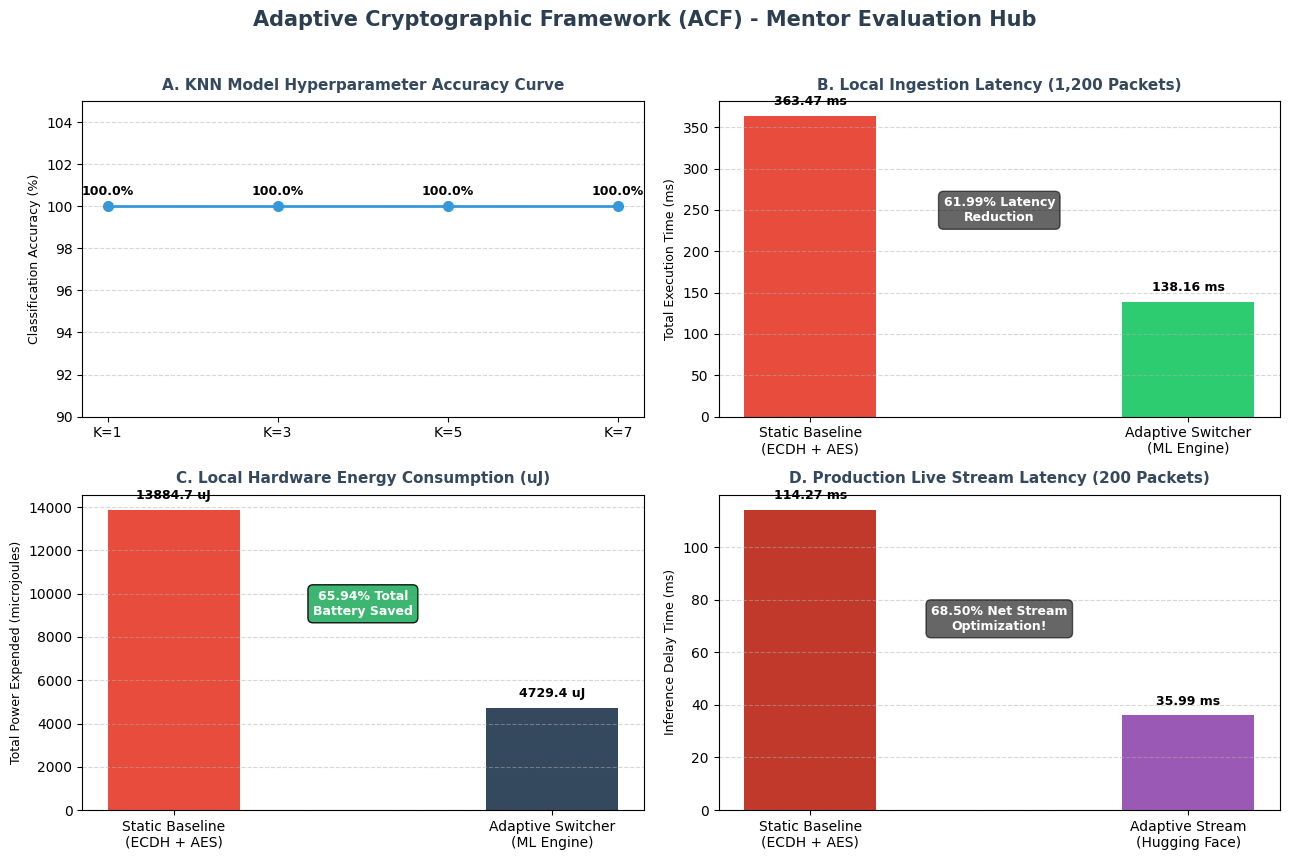

<Figure size 640x480 with 0 Axes>

In [ ]:
%run view_results_dashboard.py

In [ ]:
%run test_production_streams.py


🎬 INITIALIZING STREAM INGESTION TEST TIER
📡 Target Hub Source: 'ai4privacy/pii-masking-300k'
📋 Record Count Limit: 200 streaming packets

📦 Establishing connection and streaming records from Hugging Face Hub...
🎬 Processing streaming packets through Adaptive Cryptographic Switcher...
----------------------------------------------------------------------
 Packet #00 | Size: 0.44KB | KNN State: 🟢 PUBLIC   | Threat Flag: 1 -> Routed to Cipher Tier 2
 Packet #01 | Size: 0.44KB | KNN State: 🟢 PUBLIC   | Threat Flag: 0 -> Routed to Cipher Tier 1
 Packet #02 | Size: 0.41KB | KNN State: 🟢 PUBLIC   | Threat Flag: 0 -> Routed to Cipher Tier 1
 Packet #03 | Size: 0.41KB | KNN State: 🚨 SENSITIVE | Threat Flag: 0 -> Routed to Cipher Tier 3
 Packet #04 | Size: 0.40KB | KNN State: 🚨 SENSITIVE | Threat Flag: 0 -> Routed to Cipher Tier 3
----------------------------------------------------------------------
             PRODUCTION STREAMING EVALUATION PERFORMANCE REPORT        
-----------------------